# Notebook 3: Random Forest Classifier

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (from Notebook 2)  
**Task:** Binary classification — predict whether a patient develops sepsis

---

## What this notebook does
1. Load the preprocessed train and test sets
2. Train a baseline Random Forest classifier
3. Tune hyperparameters using GridSearchCV
4. Evaluate — confusion matrix, ROC curve, feature importances

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay
)

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Sepsis ML Project')

random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## 3. Load Preprocessed Data

In [3]:
x_train = pd.read_csv(data_dir / 'X_train.csv', index_col='Patient_ID')
x_test  = pd.read_csv(data_dir / 'X_test.csv',  index_col='Patient_ID')
y_train = pd.read_csv(data_dir / 'y_train.csv', index_col='Patient_ID').squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv',  index_col='Patient_ID').squeeze()

print(f'Training set : {x_train.shape[0]} patients, {x_train.shape[1]} features')
print(f'Test set     : {x_test.shape[0]} patients, {x_test.shape[1]} features')
print(f'Sepsis rate  — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%')

Training set : 3999 patients, 23 features
Test set     : 1000 patients, 23 features
Sepsis rate  — train: 7.3%  |  test: 7.3%


**Note on `.squeeze()`:**
When we load the target data (`y_train` and `y_test`), pandas naturally puts it into a 2D table (like a spreadsheet with just one column). Adding `.squeeze()` simply flattens or "squeezes" that single column into a simple 1D list. We do this because the machine learning model prefers its target answers as a simple list rather than a table!

## 4. How Random Forest Works

A Random Forest builds a large number of decision trees, each trained on a random subset of the training data and a random subset of features. Each tree makes its own prediction, and the final output is determined by majority vote across all trees.

The randomness serves two purposes: it prevents any single tree from overfitting by making them all slightly different, and it means the ensemble as a whole is more robust than any individual tree.

**`class_weight='balanced'`:** The dataset has far more non-sepsis patients than sepsis patients. Without any adjustment, the model would focus on getting non-sepsis predictions right (because that is where most patients are) and would miss many actual sepsis cases. With `class_weight='balanced'`, the model is penalised more heavily for misclassifying the minority class (sepsis), forcing it to pay attention to both classes equally.

## 5. Baseline Random Forest

In [4]:
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=random_seed
)
baseline_rf.fit(x_train, y_train)

y_pred_base = baseline_rf.predict(x_test)
y_prob_base = baseline_rf.predict_proba(x_test)[:, 1]

print(f'F1 score : {f1_score(y_test, y_pred_base):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_base):.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Non-Sepsis', 'Sepsis']))

F1 score : 0.0000
ROC-AUC  : 0.7167

              precision    recall  f1-score   support

  Non-Sepsis       0.93      1.00      0.96       927
      Sepsis       0.00      0.00      0.00        73

    accuracy                           0.93      1000
   macro avg       0.46      0.50      0.48      1000
weighted avg       0.86      0.93      0.89      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**What just happened with our Baseline Model?**

Looking at the results above, our model achieved a high overall accuracy (93%), but its **F1 score for predicting Sepsis is exactly 0.00**.

Why? Because the model predicted that *every single patient* in the test set is healthy (Non-Sepsis). It didn't catch a single actual Sepsis case!

The red warning about "Precision being ill-defined" happens because the model made exactly zero Sepsis predictions. When the computer tries to calculate the precision score (which involves dividing by the number of Sepsis predictions), it causes a mathematical division-by-zero error.

In a hospital, a model that misses 100% of sick patients is extremely dangerous. In the next steps, we will tune the model's settings (hyperparameters) to force it to actually look for and catch these rare but critical Sepsis cases.

## 6. Hyperparameter Tuning — GridSearchCV

GridSearchCV tests every combination of the hyperparameter values we specify. For each combination, it uses **5-fold cross-validation** on the training set: it splits the training data into 5 equal parts, trains on 4 of them, evaluates on the remaining 1, and repeats 5 times so every fold is used as the evaluation set once. The score for each combination is the average F1 across all 5 folds.

We optimise for **F1 score**, not accuracy. A model that always predicts Non-Sepsis would achieve high accuracy (because most patients are non-sepsis) but would catch zero actual sepsis cases. F1 score penalises this behaviour.

| Hyperparameter | Values Tested | What it controls |
|---|---|---|
| `n_estimators` | 100, 200 | Number of trees in the forest |
| `max_depth` | None, 10, 20 | Maximum depth of each tree — None means trees grow until all leaves are pure |
| `min_samples_split` | 2, 5 | Minimum patients required at a node before it can be split further |
| `max_features` | 'sqrt', 'log2' | Number of features considered at each split — limits overfitting |

In [5]:
param_grid = {
    'n_estimators'      : [100, 200],
    'max_depth'         : [None, 10, 20],
    'min_samples_split' : [2, 5],
    'max_features'      : ['sqrt', 'log2']
}

rf = RandomForestClassifier(class_weight='balanced', random_state=random_seed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid,
    scoring='f1', cv=cv, n_jobs=-1, verbose=1
)
grid_search.fit(x_train, y_train)

print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1      : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1      : 0.1981


## 7. Evaluate the Best Model

In [6]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(x_test)
y_prob = best_rf.predict_proba(x_test)[:, 1]

print(f'F1 score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Non-Sepsis', 'Sepsis']))

F1 score : 0.0879
ROC-AUC  : 0.6965

              precision    recall  f1-score   support

  Non-Sepsis       0.93      0.98      0.96       927
      Sepsis       0.22      0.05      0.09        73

    accuracy                           0.92      1000
   macro avg       0.58      0.52      0.52      1000
weighted avg       0.88      0.92      0.89      1000



**Did tuning the model help?**

Yes, but only a tiny bit!

* **We are finally catching *some* cases:** In our baseline model, the F1 score for Sepsis was exactly 0.00. Now it has bumped up to 0.09.
* **Recall (0.05):** This number tells us that out of all the patients who actually had Sepsis, our model successfully identified about 5% of them. That's better than missing 100% of them, but still dangerously low for a hospital setting.
* **Precision (0.22):** This means that when the model *does* ring the alarm and predict "Sepsis", it is only correct about 22% of the time (meaning there are still quite a few false alarms).

**The takeaway:** Even after testing many different settings, the Random Forest model is still really struggling to handle the fact that Sepsis cases are so rare compared to healthy patients.

## 8. Confusion Matrix

The confusion matrix shows the four possible outcomes for a binary classifier:

- **True Negatives (TN):** Correctly predicted as Non-Sepsis
- **False Positives (FP):** Non-Sepsis patients incorrectly flagged as Sepsis (false alarm)
- **False Negatives (FN):** Sepsis patients missed by the model (the most dangerous error clinically)
- **True Positives (TP):** Sepsis patients correctly identified

In a clinical setting, False Negatives are particularly costly — a missed sepsis case can be fatal. This is another reason why we use F1 score and `class_weight='balanced'`.

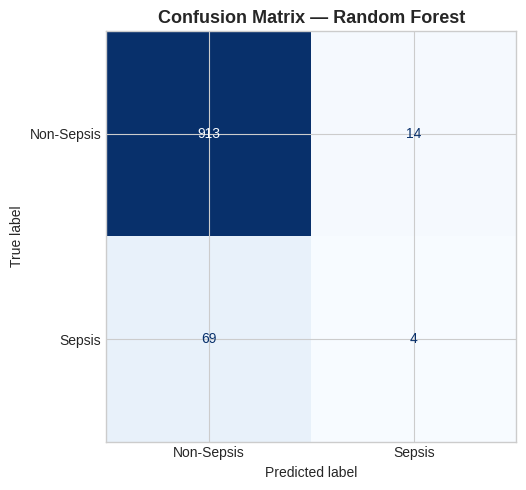

True Negatives  (correct non-sepsis) : 913
False Positives (false alarm)         : 14
False Negatives (missed sepsis)       : 69
True Positives  (caught sepsis)       : 4


In [7]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Non-Sepsis', 'Sepsis']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'True Negatives  (correct non-sepsis) : {tn}')
print(f'False Positives (false alarm)         : {fp}')
print(f'False Negatives (missed sepsis)       : {fn}')
print(f'True Positives  (caught sepsis)       : {tp}')

## 9. ROC Curve

The ROC curve plots the True Positive Rate (how many sepsis cases we catch) against the False Positive Rate (how many non-sepsis patients we incorrectly flag) at every possible classification threshold.

The **AUC** (Area Under the Curve) summarises the curve in a single number. AUC = 1.0 is perfect. AUC = 0.5 means the model is no better than random guessing. The diagonal dashed line represents a random classifier.

AUC measures the model's ability to rank sepsis patients above non-sepsis patients — it is independent of the threshold chosen.

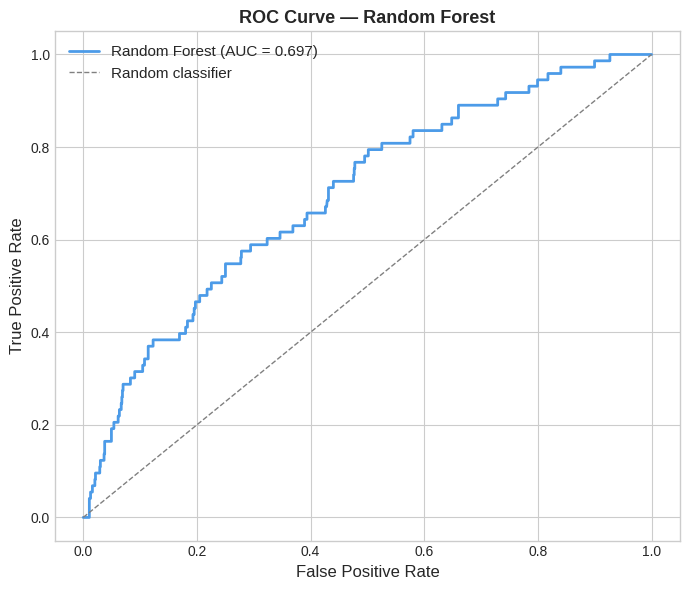

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc         = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#4C9BE8', linewidth=2,
        label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
        label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Interpreting the ROC Curve**

An AUC (Area Under the Curve) of 1.0 represents a perfect model, while 0.5 means the model is no better than randomly guessing (the dashed gray line).

Our Random Forest model achieved an AUC of approximately **0.697**. In simple terms, this means that if we randomly select one patient with Sepsis and one healthy patient, there is about a 70% chance our model will correctly assign a higher risk score to the patient who actually has Sepsis.

While 0.70 is better than a coin flip, it is still fairly weak for a medical diagnostic tool. A strong clinical model usually aims for an AUC well above 0.80 or 0.90. This further confirms that Random Forest is having a hard time clearly separating the Sepsis patients from the healthy ones.

## 10. Feature Importances

Random Forest computes a **feature importance** score for each input feature. This measures how much that feature reduced impurity (uncertainty) across all the decision splits in all trees on average. A higher score means the model relied on that feature more when making predictions.

These top features are the clinical measurements that are most predictive of sepsis in this dataset.

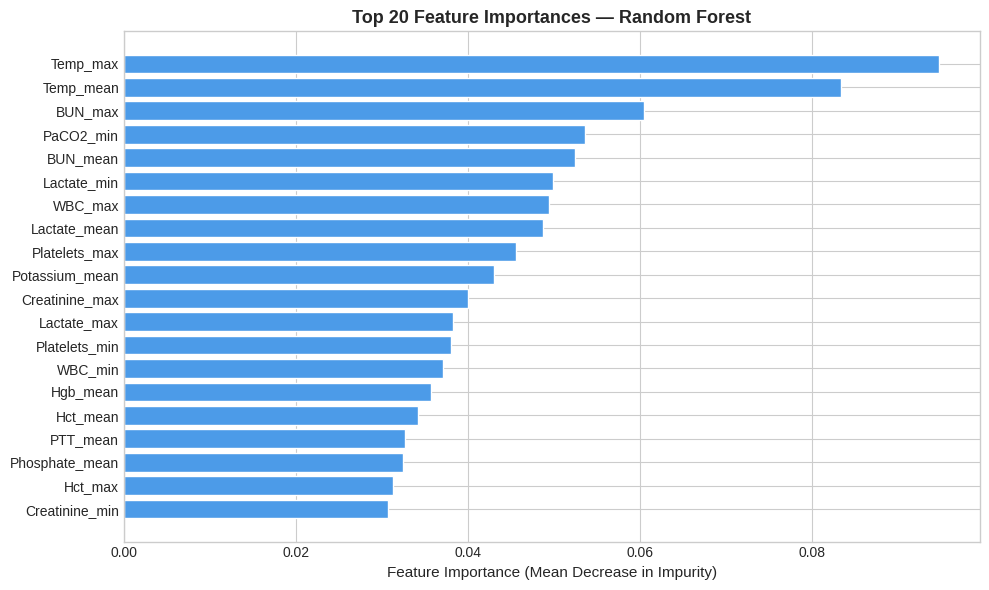

       feature  importance
      Temp_max    0.094853
     Temp_mean    0.083369
       BUN_max    0.060485
     PaCO2_min    0.053588
      BUN_mean    0.052467
   Lactate_min    0.049878
       WBC_max    0.049400
  Lactate_mean    0.048725
 Platelets_max    0.045610
Potassium_mean    0.043081


In [9]:
feat_imp = pd.DataFrame({
    'feature'    : x_train.columns,
    'importance' : best_rf.feature_importances_
}).sort_values('importance', ascending=False)

top_n = min(20, len(feat_imp))
top   = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['feature'][::-1], top['importance'][::-1],
        color='#4C9BE8', edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importances — Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(feat_imp.head(10).to_string(index=False))

## How can we improve our predictions?

Since our Random Forest model is still missing a significant number of Sepsis cases, here are a few ways we could improve our approach:

1. **Adjust the Decision Threshold:** By default, the model only predicts "Sepsis" if it is more than 50% confident. For life-threatening conditions, we can manually lower this threshold (e.g., to 15% or 20%) so the model rings the alarm more easily. We will get more false alarms, but we will catch far more actual cases.
2. **Advanced Data Resampling (SMOTE):** Instead of just telling the model to weigh the classes differently (`class_weight='balanced'`), we can use techniques like SMOTE (Synthetic Minority Over-sampling Technique) to artificially generate new, realistic Sepsis patient data for the model to train on.
3. **Feature Engineering:** We could create new, smarter features. For example, instead of just looking at the `max` and `min` temperature, we could calculate the *rate of change* of a patient's vitals over time, which might be a stronger early warning sign of Sepsis.
4. **More Extensive Tuning:** We only tested a small handful of hyperparameter combinations. Given more time and computing power, we could use `RandomizedSearchCV` to test thousands of different settings to find a better configuration.

**Alternative Model: Gradient Boosting (XGBoost)**
While Random Forest builds many independent decision trees at the same time, **Gradient Boosting** algorithms (like XGBoost or LightGBM) build trees one by one, where each new tree focuses specifically on fixing the mistakes made by the previous ones. Because Gradient Boosting is explicitly designed to focus on the hardest-to-predict cases, it usually performs much better on highly imbalanced clinical data like ours.

## 11. Summary

In [11]:
print('RANDOM FOREST — RESULTS')
print()
print(f'Best parameters : {grid_search.best_params_}')
print(f'F1 score        : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC         : {roc_auc_score(y_test, y_prob):.4f}')
print(f'True positives  : {tp}')
print(f'False negatives : {fn}')
print()
print('Next: run 04_xgboost.ipynb')

RANDOM FOREST — RESULTS

Best parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
F1 score        : 0.0879
ROC-AUC         : 0.6965
True positives  : 4
False negatives : 69

Next: run 04_xgboost.ipynb
